In [ ]:
!pip install gensim openpyxl nltk -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 20.3 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

# Load your dataset
df = pd.read_excel("/content/drive/MyDrive/scraping/FINAL PREPROCESSED DOC.xlsx")

print("Rows:", df.shape[0])
df.head()


Rows: 1030


,Query,Position,Title,Authors,Journal,Publication Info,Year,Citations,Abstract,PDF Link,Scholar Link,DOI,FULL_TEXT_CORPUS,CLEANED_TEXT,FILTERED_TOKENS,LEMMATIZED_TOKENS
0,Impact of covid 19 on mental health,2,The COVID‐19 pandemic and mental health impacts,"K Usher, J Durkin, N Bhullar",… journal of mental health nursing,"… journal of mental health nursing, 2020 - pmc...",2020.0,995,"… novel coronavirus, COVID-19, was first repor...",https://pmc.ncbi.nlm.nih.gov/articles/PMC72621...,https://pmc.ncbi.nlm.nih.gov/articles/PMC7262128/,NaN,editorial Int J Ment Health Nurs . 2020 Apr 10...,editorial int j ment health nurs apr the covid...,"editorial,int,ment,nurs,apr,impacts,kim,usher,...","editorial,int,ment,nurs,apr,impact,kim,usher,k..."
1,Impact of covid 19 on mental health,4,Impact of COVID-19 pandemic on mental health,J Heitzman,Psychiatr Pol,"Psychiatr Pol, 2020 - scholar.archive.org",2020.0,273,"… , the symptomatic spectrum of mental disorde...",https://scholar.archive.org/work/clvic3iwoff4l...,https://scholar.archive.org/work/clvic3iwoff4l...,NaN,You've reached the limit for the number of req...,you ve reached the limit for the number of req...,"reached,limit,requests,made,short,please,wait,...","reach,limit,request,make,short,please,wait,mom..."
2,Impact of covid 19 on mental health,6,The impact of the COVID-19 pandemic on the men...,"F Ornell, SC Halpern, FHP Kessler…",Cadernos de saude …,"Cadernos de saude …, 2020 - SciELO Public Health",2020.0,601,… psychological responses and associated facto...,NaN,https://www.scielosp.org/article/csp/2020.v36n...,NaN,The 2019 novel coronavirus pandemic (COVID-19)...,the novel coronavirus pandemic is an internati...,"novel,international,emergency,unprecedented,mo...","novel,international,emergency,unprecedented,mo..."
3,Impact of covid 19 on mental health,7,Mental health and the COVID-19 pandemic,"B Gavin, J Lyne, F McNicholas",Irish journal of psychological …,"Irish journal of psychological …, 2020 - cambr...",2020.0,215,… to mental health and the COVID-19 … COVID-19...,https://www.cambridge.org/core/services/aop-ca...,https://www.cambridge.org/core/journals/irish-...,NaN,Mental health and the COVID-19 pandemic B. Gav...,mental health and the pandemic b gavin j lyne ...,"gavin,lyne,mcnicholas,department,child,adolesc...","gavin,lyne,mcnicholas,department,child,adolesc..."
4,Impact of covid 19 on mental health,9,The mental health impact of the COVID-19 pande...,"KS Khan, MA Mamun, MD Griffiths, I Ullah",… journal of mental health and …,"… journal of mental health and …, 2022 - Springer",2022.0,501,… These mental health and emotional issues are...,https://link.springer.com/content/pdf/10.1007/...,https://link.springer.com/article/10.1007/s114...,NaN,LETTER TO THE EDITOR The Mental Health Impact ...,letter to the editor the mental health impact ...,"letter,across,different,cohorts,kiran,shafiq,k...","letter,across,different,cohort,kiran,shafiq,kh..."


In [ ]:

# STEP 1: FEATURE ENGINEERING FOR LDA



# 0. Install gensim (if needed)
!pip install gensim


# 1. Import libraries
import pandas as pd
import os
import pickle
from gensim.models.phrases import Phrases, Phraser
from gensim.corpora import Dictionary
from gensim.models import TfidfModel
from google.colab import drive

# 2. Load dataset
df = pd.read_excel("/content/drive/MyDrive/scraping/FINAL PREPROCESSED DOC.xlsx")

print("Dataset shape:", df.shape)
print("Columns:", df.columns)


# 3. Extract tokens

texts = df["LEMMATIZED_TOKENS"].dropna().apply(
    lambda x: [w.strip() for w in str(x).split(",") if w.strip() != ""]
).tolist()

print("\nExample tokens BEFORE bigrams:")
print(texts[0][:20])


# 4. Build Bigram Model

bigram_model = Phrases(
    texts,
    min_count=5,     # appear in at least 5 documents
    threshold=10     # higher = fewer phrases
)

bigram_phraser = Phraser(bigram_model)

texts_bigrams = [bigram_phraser[doc] for doc in texts]

print("\nExample tokens AFTER bigrams:")
print(texts_bigrams[0][:20])


# 5. Create Dictionary

dictionary = Dictionary(texts_bigrams)

dictionary.filter_extremes(
    no_below=5,     # remove rare words
    no_above=0.5    # remove overly common words
)

print("\nDictionary size:", len(dictionary))


# 6. Create Bag-of-Words Corpus

corpus_bow = [dictionary.doc2bow(doc) for doc in texts_bigrams]

print("\nExample Bag-of-Words:")
print(corpus_bow[0][:10])


# 7. Apply TF-IDF (Optional)

tfidf_model = TfidfModel(corpus_bow)
corpus_tfidf = list(tfidf_model[corpus_bow])

print("\nExample TF-IDF:")
print(corpus_tfidf[0][:10])


# 8. Save Outputs to Drive

drive.mount('/content/drive')

save_path = "/content/drive/MyDrive/LDA_Project2/"
os.makedirs(save_path, exist_ok=True)

# Save dictionary
dictionary.save(save_path + "lda_dictionary.gensim")

# Save Bag-of-Words
with open(save_path + "lda_corpus_bow.pkl", "wb") as f:
    pickle.dump(corpus_bow, f)

# Save TF-IDF
with open(save_path + "lda_corpus_tfidf.pkl", "wb") as f:
    pickle.dump(corpus_tfidf, f)

# Save bigram texts
with open(save_path + "lda_texts_bigrams.pkl", "wb") as f:
    pickle.dump(texts_bigrams, f)

print("\n✅ STEP 1 COMPLETE AND SAVED TO DRIVE")
print("Saved in:", save_path)

Dataset shape: (1030, 16)
Columns: Index(['Query', 'Position', 'Title', 'Authors', 'Journal', 'Publication Info',
       'Year', 'Citations', 'Abstract', 'PDF Link', 'Scholar Link', 'DOI',
       'FULL_TEXT_CORPUS', 'CLEANED_TEXT', 'FILTERED_TOKENS',
       'LEMMATIZED_TOKENS'],
      dtype='object')

Example tokens BEFORE bigrams:
['editorial', 'int', 'ment', 'nurs', 'apr', 'impact', 'kim', 'usher', 'kim', 'usher', 'dipapph', 'nsg', 'mnst', 'phd', 'facmhn', 'school', 'new', 'england', 'armidale', 'new']

Example tokens AFTER bigrams:
['editorial', 'int_ment', 'nurs', 'apr', 'impact', 'kim', 'usher', 'kim', 'usher', 'dipapph', 'nsg', 'mnst', 'phd', 'facmhn', 'school', 'new_england', 'armidale', 'new_south', 'wale_australia', 'find_article']

Dictionary size: 18225

Example Bag-of-Words:
[(0, 2), (1, 1), (2, 1), (3, 1), (4, 1), (5, 3), (6, 1), (7, 1), (8, 2), (9, 1)]

Example TF-IDF:
[(0, np.float64(0.01356782328213356)), (1, np.float64(0.02142417703937002)), (2, np.float64(0.0130150665

In [ ]:
import warnings
warnings.filterwarnings("ignore")



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Model and data loaded successfully

--- Results ---
     Topic                                    Top 50 Keywords  Coherence
0  Topic 1  social_medium, child, system, access, medical,...   0.366581
1  Topic 2  nto, zkw, kznoytm, yoz, ltr, okwozmo, klwo, mk...   0.963703
2  Topic 3  woman, order, child, death, pregnancy, materna...   0.323751
3  Topic 4  student, nurse, hcws, fear, death, burnout, ho...   0.469413
4  Topic 5  child, lockdown, item, depression_anxiety, anx...   0.377445

✅ Saved to: /content/drive/MyDrive/LDA_Project/topic_keywords_coherence_300.csv

--- Loaded File Preview ---
     Topic                                    Top 50 Keywords  Coherence
0  Topic 1  social_medium, child, system, access, medical,...   0.366581
1  Topic 2  nto, zkw, kznoytm, yoz, ltr, okwozmo, klwo, mk...   0.963703
2  Topic 3  woman, order, child, death, pregnancy,

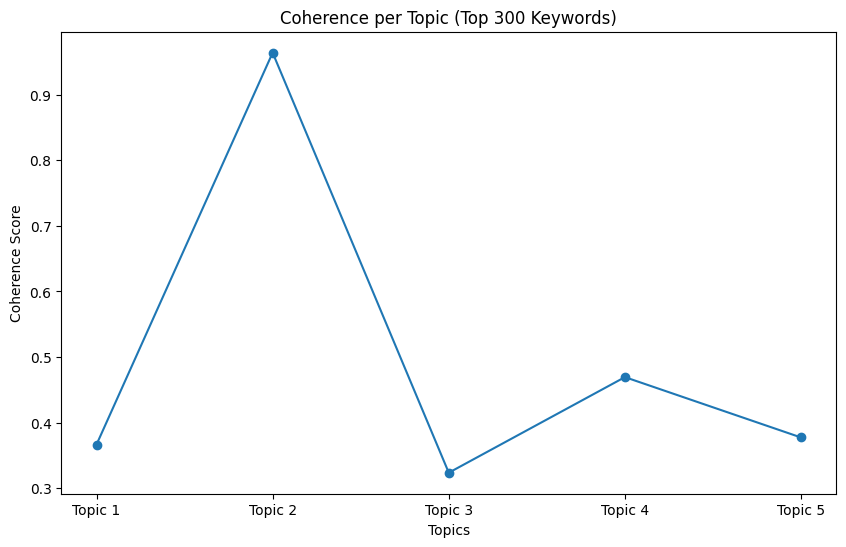

In [ ]:
# =========================================================
# STEP: KEYWORD EXTRACTION (50) + COHERENCE PER TOPIC + SAVE
# =========================================================

import pickle
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
from gensim.corpora import Dictionary
from gensim.models import LdaModel, CoherenceModel

# ---------------------------------------------------------
# 1. Mount Drive
# ---------------------------------------------------------
drive.mount('/content/drive')

load_path = "/content/drive/MyDrive/LDA_Project/"

# ---------------------------------------------------------
# 2. Load Data
# ---------------------------------------------------------
dictionary = Dictionary.load(load_path + "lda_dictionary.gensim")

with open(load_path + "lda_corpus_bow.pkl", "rb") as f:
    corpus_bow = pickle.load(f)

with open(load_path + "lda_texts_bigrams.pkl", "rb") as f:
    texts_bigrams = pickle.load(f)

final_lda_model = LdaModel.load(load_path + "final_lda_model.gensim")

print("✅ Model and data loaded successfully")

# ---------------------------------------------------------
# 3. Extract TOP 50 Keywords per Topic
# ---------------------------------------------------------
num_words = 300

topics = []
keywords_list = []
coherence_scores = []

for topic_id in range(final_lda_model.num_topics):

    # Extract words
    words = final_lda_model.show_topic(topic_id, topn=num_words)
    word_list = [w for w, _ in words]

    # Compute coherence for THIS topic using its 50 words
    cm = CoherenceModel(
        topics=[word_list],
        texts=texts_bigrams,
        dictionary=dictionary,
        coherence='c_v'
    )
    coherence = cm.get_coherence()

    # Store results
    topics.append(f"Topic {topic_id+1}")
    keywords_list.append(", ".join(word_list))
    coherence_scores.append(coherence)

# ---------------------------------------------------------
# 4. Create DataFrame
# ---------------------------------------------------------
df = pd.DataFrame({
    "Topic": topics,
    "Top 50 Keywords": keywords_list,
    "Coherence": coherence_scores
})

print("\n--- Results ---")
print(df)

# ---------------------------------------------------------
# 5. Save Results to Drive
# ---------------------------------------------------------
save_file = load_path + "topic_keywords_coherence_300.csv"
df.to_csv(save_file, index=False)

print(f"\n✅ Saved to: {save_file}")

# ---------------------------------------------------------
# 6. Read the File Back (Verification)
# ---------------------------------------------------------
df_loaded = pd.read_csv(save_file)

print("\n--- Loaded File Preview ---")
print(df_loaded.head())

# ---------------------------------------------------------
# 7. Plot Coherence per Topic
# ---------------------------------------------------------
plt.figure(figsize=(10,6))

plt.plot(df["Topic"], df["Coherence"], marker='o')

plt.xlabel("Topics")
plt.ylabel("Coherence Score")
plt.title("Coherence per Topic (Top 300 Keywords)")

plt.show()